# Лабораторная работа №1
## Фильтрация шумов на полутоновых изображениях

1. Считать цветное rgb изображение.
2. Преобразовать изображение в градации серого.
3. Зашумить изображение аддитивным шумом с вероятностью p (по вариантам).
  *   Вход: изображение из пункта 2
  *   Вывод: зашумленное изображение
4. Написать функцию реализации свертки (прохождение окном по изображению)
5. Написать функцию реализации свертки (с помощью преобразования фурье)
6. Написать функцию реализации кросс-кореляции (с помощью функции свертки через фурье преобразование).

> Функции вида fun(mat1, mat2)  
Где mat1  - первый сигнал, а mat2 - второй сигнал.

7. Вычислить отсчеты функции  взаимной корреляции между исходным изображением и зашумленным (B<sub>xy</sub>). Вывести получившуюся матрицу как изображение.
8. Вычислить отсчеты функции  автокорреляции зашумленного изображения (B<sub>y</sub>). Вывести получившуюся матрицу как изображение.
9. Составить матрицы отсчетов для решения системы уравнений Винера-Хопфа для заданной области D.
10. Решить полученную СЛАУ (numpy.linalg.solve). На основе вектора решений построить матрицу КИХ фильтра.
11. Отфильтровать изображение полученным КИХ фильтром. Подсчитать СКО (RMSE).
  *   Вход: изображение из пункта 3
  *   Вывод: Значения СКО (RMSE). Исходное (из пункта 2), зашумленное (из пункта 3) и отфильтрованное изображение.
  *   СКО (RMSE) считать между отфильтрованным изображением и исходным (не зашумленным) из пункта 2

  
    
    
*Для работы с изображением использовать OpenCV (открытие, сохранение и т.д.). Для визуализации можно использовать matplotlib. Все необходимые для задания функции реализовавать самим, а не использовать готовые в OpenCV, если не указано обратного.*
  
  
  

---



> По всем вопросам писать на почту  ***cybersouls@yandex.ru*** или в ЛС в VK/tg




Ссылки на полезные ресурсы:

1.   [Методичка по фильтрации изображений](https://drive.google.com/file/d/1djgQ_WEGl1irIxzb4-8slpP3ZIJP_i9C/view?usp=drive_link)
2.    [Методичка по теории обработки сигналов( там свертка, КИХ фильтр и т.д. )](https://drive.google.com/file/d/1Lnskznr5WW4ZjqmMC5JOZdg0nFtOlyGX/view?usp=sharing)
2.    [Документация OpenCV](https://docs.opencv.org/4.x/index.html)

# Варианты задания


№ варианта | Вероятность p | Область D
--- | :---: | :---:
1 | 0,1 | {(-1,-1), ... , (1,1)}
2 | 0,08 | {(0,0), ... , (2,2)}
3 | 0,11 | {(-2,-2), ... , (0,0)}
4 | 0,09 | {(-3,-3), ... , (-1,-1)}
5 | 0,13 | {(-1,-1), ... , (2,2)}
6 | 0,09 | {(-2,-2), ... , (1,1)}
7 | 0,12 | {(0,0), ... , (3,3)}
8 | 0,14 | {(1,1), ... , (3,3)}
9 | 0,17 | {(-3,-3), ... , (0,0)}
10 | 0,09 | {(0,0), ... , (2,2)}
11 | 0,08 | {(-1,-1), ... , (3,3)}
12 | 0,07 | {(-3,-3), ... , (3,3)}
13 | 0,08 | {(-2,-2), ... , (2,2)}
14 | 0,1 | {(-2,-2), ... , (3,3)}
15 | 0,06 | {(-3,-3), ... , (2,2)}


# Контрольные темы

1. Свёртка последовательностей.
2. Линейная фильтрация. Основные понятия.
3. КИХ фильтр.

## Решение

Вариант 3

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

P_NOISE = 0.11
D_MIN, D_MAX = -2, 0

IMG_SIZE = (255, 255)
RNG = np.random.default_rng(1)

### 1. Считать цветное rgb изображение.

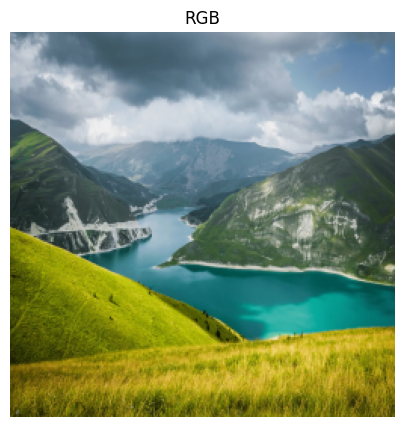

In [14]:
def read_rgb(path: str, size=IMG_SIZE) -> np.ndarray:
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Не удалось прочитать файл: {path}")
    bgr = cv2.resize(bgr, size, interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb

IMAGE_PATH = "image.jpg"
rgb = read_rgb(IMAGE_PATH)

plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.axis("off")
plt.title("RGB")
plt.show()

### 2. Преобразовать изображение в градации серого.

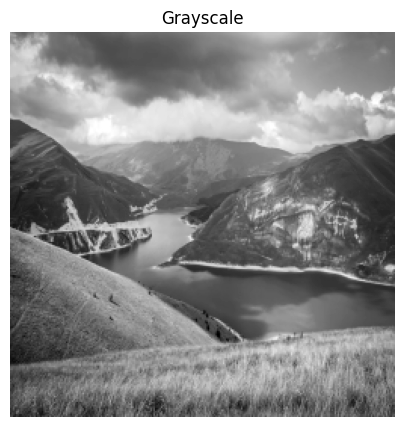

In [15]:
gray = np.dot(rgb[..., :3], [0.299, 0.587, 0.114])

plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Grayscale")
plt.show()

### 3. Зашумить изображение аддитивным шумом с вероятностью p (по вариантам).

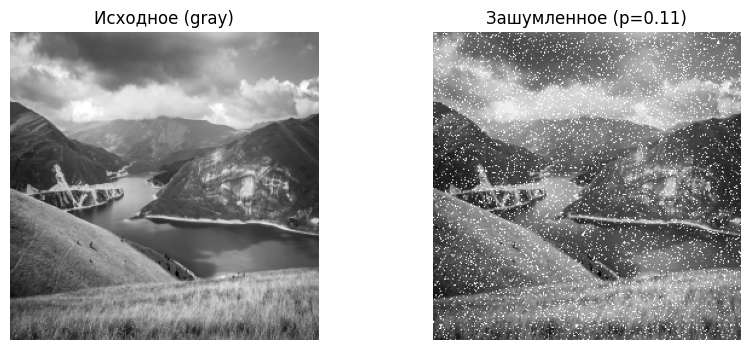

In [16]:
def add_additive_noise_prob(img_gray: np.ndarray, p: float, rng: np.random.Generator) -> np.ndarray:
    img = img_gray.astype(np.int16)
    mask = (rng.random(img_gray.shape) <= p)
    noise = rng.integers(0, 256, img_gray.shape, dtype=np.int16)
    # сумма полезного сигнала и случайного сигнала
    noisy = img + noise * mask.astype(np.int16)
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

noisy = add_additive_noise_prob(gray, P_NOISE, RNG)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Исходное (gray)")

plt.subplot(1, 2, 2)
plt.imshow(noisy, cmap="gray")
plt.axis("off")
plt.title(f"Зашумленное (p={P_NOISE})")
plt.show()

### 4. Написать функцию реализации свертки (прохождение окном по изображению)

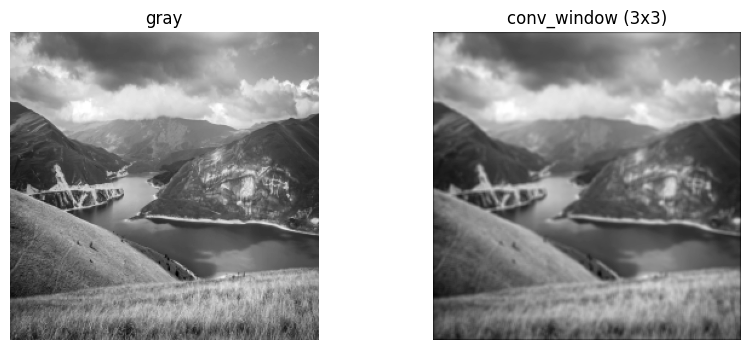

In [17]:
def conv_window(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    img = image.astype(np.float64)
    ker = kernel.astype(np.float64)

    kh, kw = ker.shape

    pad_h, pad_w = kh // 2, kw // 2
    ker_rot = np.rot90(ker, 2)  # свёртка = разворот ядра на 180
    #ker_rot = ker
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode="constant")
    out = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            patch = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(patch * ker_rot)

    return out

kernel_3 = np.ones((3, 3), dtype=np.float64) / 9.0
test_blur = conv_window(gray, kernel_3)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("gray")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(test_blur, 0, 255).astype(np.uint8), cmap="gray")
plt.axis("off")
plt.title("conv_window (3x3)")
plt.show()


### 5. Написать функцию реализации свертки (с помощью преобразования фурье)

In [18]:
def fft_convolve_full(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a.astype(np.float64)
    b = b.astype(np.float64)

    Ha, Wa = a.shape
    Hb, Wb = b.shape
    P, Q = Ha + Hb - 1, Wa + Wb - 1

    Fa = np.fft.fft2(a, (P, Q)) 
    # дополняем нулями для совпадения циклической и линейной свертки
    Fb = np.fft.fft2(b, (P, Q)) 
    # умножение в частотной области
    full = np.fft.ifft2(Fa * Fb).real # в результате линейная свёртка

    start_r, start_c = Hb // 2, Wb // 2
    return full[start_r:start_r + Ha, start_c:start_c + Wa]


test_blur_fft = fft_convolve_full(gray, kernel_3)
print("max|diff| window vs fft:", np.max(np.abs(test_blur - test_blur_fft)))


max|diff| window vs fft: 4.263256414560601e-13


### 6. Написать функцию реализации кросс-кореляции (с помощью функции свертки через фурье преобразование).

In [19]:
def flip2(mat: np.ndarray) -> np.ndarray:
    # поворот матрицы на 180 градусов
    return np.flipud(np.fliplr(mat))

def cross_corr_fft_centered(mat1: np.ndarray, mat2: np.ndarray) -> np.ndarray:
    H, W = mat1.shape

    # корреляция = свёртка mat1 с перевёрнутым mat2
    corr = fft_convolve_full(mat1, flip2(mat2))  # размер (2H-1, 2W-1)
    return corr

### 7. Вычислить отсчеты функции  взаимной корреляции между исходным изображением и зашумленным (B<sub>xy</sub>). Вывести получившуюся матрицу как изображение.

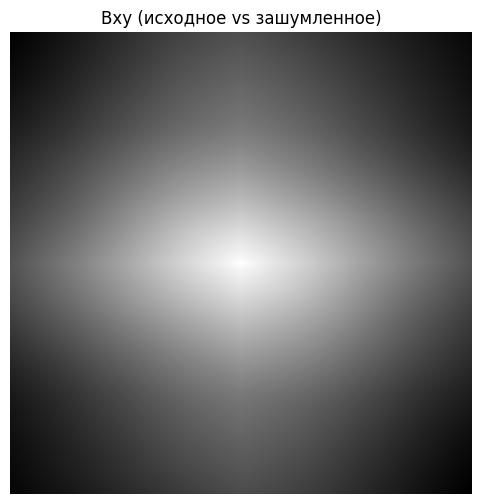

Bxy shape: (255, 255) min/max: 256852320.6450003 1206216816.2670007


In [20]:
Bxy = cross_corr_fft_centered(gray, noisy)

plt.figure(figsize=(6, 6))
plt.imshow(Bxy, cmap="gray")
plt.axis("off")
plt.title("Bxy (исходное vs зашумленное)")
plt.show()

print("Bxy shape:", Bxy.shape, "min/max:", float(Bxy.min()), float(Bxy.max()))

### 8. Вычислить отсчеты функции  автокорреляции зашумленного изображения (B<sub>y</sub>). Вывести получившуюся матрицу как изображение.

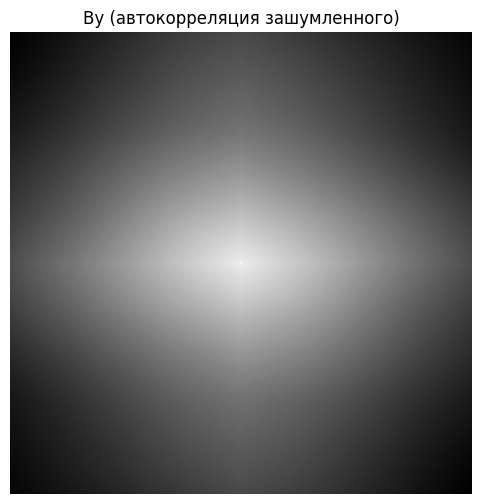

By shape: (255, 255) min/max: 281002659.00000006 1358179001.000001


In [21]:
By = cross_corr_fft_centered(noisy, noisy)

plt.figure(figsize=(6, 6))
plt.imshow(By, cmap="gray")
plt.axis("off")
plt.title("By (автокорреляция зашумленного)")
plt.show()

print("By shape:", By.shape, "min/max:", float(By.min()), float(By.max()))

### 9. Составить матрицы отсчетов для решения системы уравнений Винера-Хопфа для заданной области D.

$\sum\sum$ h(k,l) * By(m-k, n-l) = Bxy(-m, -n)

In [22]:
def build_wiener_hopf(By: np.ndarray, Bxy: np.ndarray, d_min: int, d_max: int):
    H, W = By.shape
    cx, cy = H // 2, W // 2

    N = d_max - d_min + 1
    N2 = N * N

    # преобразует координаты в линейный индекс
    def idx(m: int, n: int) -> int:
        return (m - d_min) * N + (n - d_min)

    coords = [(m, n) for m in range(d_min, d_max + 1) for n in range(d_min, d_max + 1)]

    G = np.zeros((N2, N2), dtype=np.float64)
    Y = np.zeros((N2, 1), dtype=np.float64)

    for (m, n) in coords:
        i = idx(m, n)
        # Y(m,n) = Bxy(-m,-n) => в нашей центрированной матрице это индекс (cx-m, cy-n)
        Y[i, 0] = Bxy[cx - m, cy - n]

        for (k, l) in coords:
            j = idx(k, l)
            # G((m,n),(k,l)) = By(m-k, n-l) => индекс (cx+(m-k), cy+(n-l))
            G[i, j] = By[cx + (m - k), cy + (n - l)]

    return G, Y, N

G, Y, N = build_wiener_hopf(By, Bxy, D_MIN, D_MAX)
print("G shape:", G.shape, "Y shape:", Y.shape, "N:", N)

G shape: (9, 9) Y shape: (9, 1) N: 3


### 10. Решить полученную СЛАУ (numpy.linalg.solve). На основе вектора решений построить матрицу КИХ фильтра.

g:
[[0.0156256  0.03185899 0.07638887]
 [0.05033524 0.07685662 0.1395662 ]
 [0.11962944 0.16136009 0.25927255]]


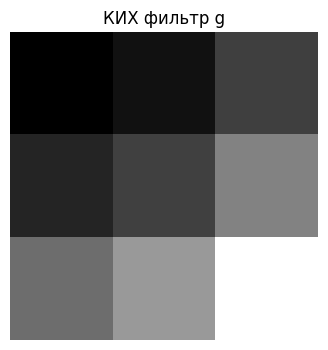

In [23]:
g_vec = np.linalg.solve(G, Y)
g = g_vec.reshape(N, N)

print("g:")
print(g)

plt.figure(figsize=(4, 4))
plt.imshow(g, cmap="gray")
plt.axis("off")
plt.title("КИХ фильтр g")
plt.show()

### 11. Отфильтровать изображение полученным КИХ фильтром. Подсчитать СКО (RMSE).

RMSE(gray, noisy): 35.02842961415334
RMSE(gray, restored): 17.75162965996616


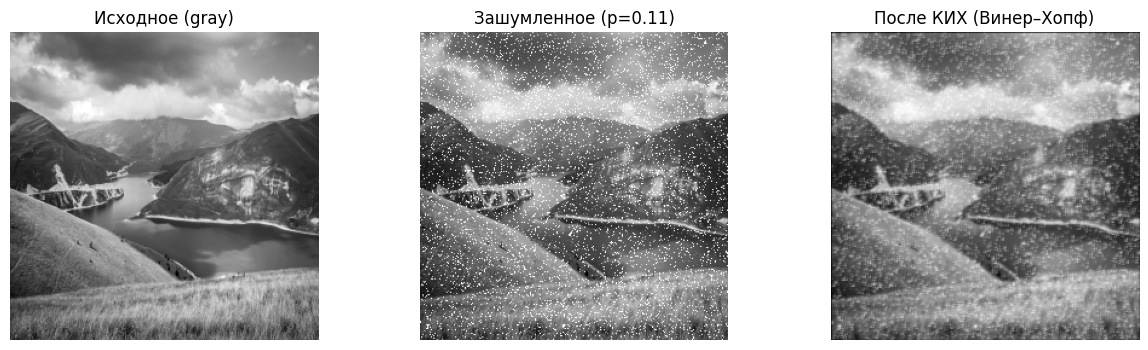

In [24]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return float(np.sqrt(np.mean((a - b) ** 2)))

restored = fft_convolve_full(noisy, g)

rmse_noisy = rmse(gray, noisy)
rmse_restored = rmse(gray, restored)

print("RMSE(gray, noisy):", rmse_noisy)
print("RMSE(gray, restored):", rmse_restored)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.title("Исходное (gray)")

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap="gray")
plt.axis("off")
plt.title(f"Зашумленное (p={P_NOISE})")

plt.subplot(1, 3, 3)
plt.imshow(restored, cmap="gray")
plt.axis("off")
plt.title("После КИХ (Винер–Хопф)")
plt.show()